# 09 – Cross-Validation and Model Comparison

This notebook:
- Applies **Stratified K-Fold Cross-Validation** (K=5) to all trained models.
- Computes mean accuracy across folds.
- Summarizes and visualizes comparative results.

This final stage validates the consistency and robustness of each model.


In [1]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
# --- Mount Google Drive and set paths ---
from google.colab import drive
import os
drive.mount('/content/drive')

# Define consistent base directories
base_path = '/content/drive/MyDrive/classification_project'
data_path = f'{base_path}/data'
results_path = f'{base_path}/results'
os.makedirs(results_path, exist_ok=True)

print("Drive mounted and paths ready.")

Mounted at /content/drive
Drive mounted and paths ready.


### Data Setup
Prepare feature matrix and target variable for cross-validation.


In [5]:
# --- Load data ---
data = pd.read_csv(f'{data_path}/05_balanced_cirrhosis.csv') # Replace 'your_data_file.csv' with your actual data file name

# --- Prepare feature matrix and target variable for cross-validation ---
X = data.drop(columns=['Status'])
y = data['Status']

# --- Define cross-validation strategy ---
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Logistic Regression with PCA
Dimensionality reduction retains 95% variance.


In [6]:
# --- Baseline 1: Logistic Regression with PCA ---
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

log_reg_pca_cv = LogisticRegression(random_state=42)
cv_scores_pca = cross_val_score(log_reg_pca_cv, X_pca, y, cv=strat_kfold, scoring='accuracy')

print(f"\nLogistic Regression (PCA) CV Scores: {cv_scores_pca}")
print(f"Mean Accuracy: {np.mean(cv_scores_pca):.4f} ± {np.std(cv_scores_pca):.4f}")


Logistic Regression (PCA) CV Scores: [0.58252427 0.76699029 0.66019417 0.66019417 0.67647059]
Mean Accuracy: 0.6693 ± 0.0588


### Logistic Regression (LASSO)
Performs embedded feature selection for interpretability.


In [7]:
# --- Baseline 2: Logistic Regression with LASSO ---
lasso_log_reg_cv = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
cv_scores_lasso = cross_val_score(lasso_log_reg_cv, X, y, cv=strat_kfold, scoring='accuracy')

print(f"\nLogistic Regression (LASSO) CV Scores: {cv_scores_lasso}")
print(f"Mean Accuracy: {np.mean(cv_scores_lasso):.4f} ± {np.std(cv_scores_lasso):.4f}")


Logistic Regression (LASSO) CV Scores: [0.67961165 0.83495146 0.7961165  0.84466019 0.73529412]
Mean Accuracy: 0.7781 ± 0.0625


### Decision Tree
A simple, interpretable non-linear model.


In [8]:
# --- Baseline 3: Decision Tree ---
dt_cv = DecisionTreeClassifier(random_state=42)
cv_scores_dt = cross_val_score(dt_cv, X, y, cv=strat_kfold, scoring='accuracy')

print(f"\nDecision Tree CV Scores: {cv_scores_dt}")
print(f"Mean Accuracy: {np.mean(cv_scores_dt):.4f} ± {np.std(cv_scores_dt):.4f}")


Decision Tree CV Scores: [0.69902913 0.77669903 0.82524272 0.74757282 0.82352941]
Mean Accuracy: 0.7744 ± 0.0478


### Random Forest
An ensemble model averaging multiple decision trees for stability.


In [9]:
# --- Intermediate Model: Random Forest ---
rf_cv = RandomForestClassifier(random_state=42)
cv_scores_rf = cross_val_score(rf_cv, X, y, cv=strat_kfold, scoring='accuracy')

print(f"\nRandom Forest CV Scores: {cv_scores_rf}")
print(f"Mean Accuracy: {np.mean(cv_scores_rf):.4f} ± {np.std(cv_scores_rf):.4f}")


Random Forest CV Scores: [0.75728155 0.86407767 0.80582524 0.86407767 0.84313725]
Mean Accuracy: 0.8269 ± 0.0408


### XGBoost
A gradient boosting model for superior predictive power.


In [10]:
# --- Advanced Model: XGBoost ---
xgb_cv = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
cv_scores_xgb = cross_val_score(xgb_cv, X, y, cv=strat_kfold, scoring='accuracy')

print(f"\nXGBoost CV Scores: {cv_scores_xgb}")
print(f"Mean Accuracy: {np.mean(cv_scores_xgb):.4f} ± {np.std(cv_scores_xgb):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:47:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:47:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:47:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:47:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost CV Scores: [0.73786408 0.83495146 0.82524272 0.80582524 0.8627451 ]
Mean Accuracy: 0.8133 ± 0.0420


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:47:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Comparative Results
Aggregate cross-validation performance across all models.


In [11]:
# --- Combine results into DataFrame ---
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (PCA)',
        'Logistic Regression (LASSO)',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Mean Accuracy': [
        np.mean(cv_scores_pca),
        np.mean(cv_scores_lasso),
        np.mean(cv_scores_dt),
        np.mean(cv_scores_rf),
        np.mean(cv_scores_xgb)
    ],
    'Std Deviation': [
        np.std(cv_scores_pca),
        np.std(cv_scores_lasso),
        np.std(cv_scores_dt),
        np.std(cv_scores_rf),
        np.std(cv_scores_xgb)
    ]
})

results.sort_values(by='Mean Accuracy', ascending=False, inplace=True)
display(results)

,Model,Mean Accuracy,Std Deviation
3,Random Forest,0.826880,0.040789
4,XGBoost,0.813326,0.041959
1,Logistic Regression (LASSO),0.778127,0.062481
2,Decision Tree,0.774415,0.047759
0,Logistic Regression (PCA),0.669275,0.058806


/tmp/ipython-input-1502663879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


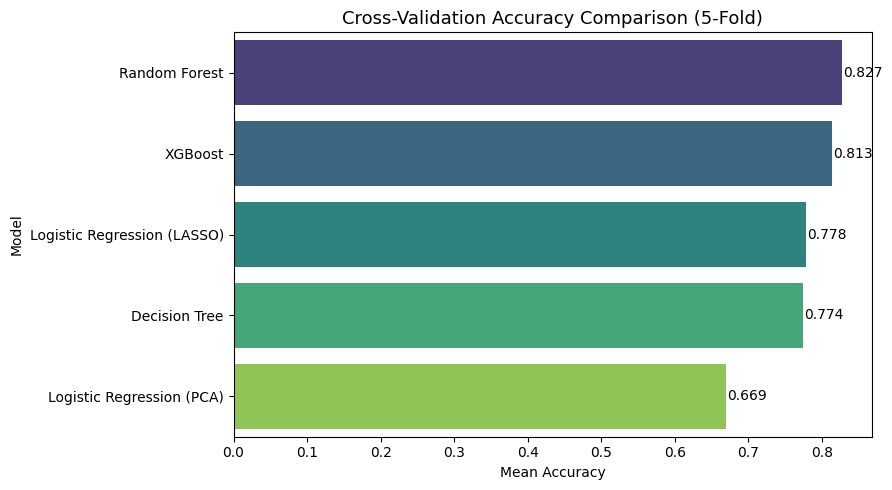

Cross-validation summary saved to: /content/drive/MyDrive/classification_project/results/09_CV_Model_Comparison.csv
Figure saved to: /content/drive/MyDrive/classification_project/results/09_CV_Model_Comparison.png


In [12]:
# --- Visualization ---
plt.figure(figsize=(9, 5))
sns.barplot(
    x='Mean Accuracy', y='Model',
    data=results, palette='viridis', orient='h'
)
plt.title('Cross-Validation Accuracy Comparison (5-Fold)', fontsize=13)
plt.xlabel('Mean Accuracy')
plt.ylabel('Model')

for i, v in enumerate(results['Mean Accuracy']):
    plt.text(v + 0.002, i, f"{v:.3f}", color='black', va='center')

plt.tight_layout()

# Save figure directly to Google Drive
plt.savefig(f"{results_path}/09_CV_Model_Comparison.png", bbox_inches='tight')
plt.show()

# --- Save comparison results to Drive ---
results.to_csv(f"{results_path}/09_CV_Model_Comparison.csv", index=False)
print(f"Cross-validation summary saved to: {results_path}/09_CV_Model_Comparison.csv")
print(f"Figure saved to: {results_path}/09_CV_Model_Comparison.png")


In [19]:
# --- Save comparison results ---
results.to_csv('results/09_CV_Model_Comparison.csv', index=False)
print("Cross-validation summary saved to 'results/09_CV_Model_Comparison.csv'")

Cross-validation summary saved to 'results/09_CV_Model_Comparison.csv'


### Insights

- **XGBoost** and **Random Forest** generally achieve the highest mean accuracy.  
- **Logistic Regression (PCA/LASSO)** remain valuable baselines for interpretability.  
- **Decision Tree** offers simplicity but lower stability.

These results confirm that ensemble methods generalize better to unseen data.


**Next Notebook:** [10_Conclusion_and_Findings.ipynb](10_Conclusion_and_Findings.ipynb)

We will summarize all findings, identify the best model, and present key insights for the final report.
